# Sujet 2 — Pyronear : Parsing et manipulation des données

Construit la table "une ligne par séquence" décrite dans la méthode suggérée :
- parsing du nom de dossier (site, azimut, date)
- lecture des labels YOLO (score max, score moyen, nb de frames positives)
- durée de la séquence (à partir des timestamps des images)
- jointure avec `sites.csv` (lat/lon)
- récupération du FWI du jour via l'API risque (avec cache local)

In [ ]:
#!pip install -r requirements.txt
from pathlib import Path
from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image

root = Path("mines_pyronear_data") #donne le chemin d'accès du dossier
root.exists()

ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


True

## 1. Parsing du nom de séquence

Récupération du format : `<site>_<azimut>_<timestamp>`.

In [3]:
def parse_seq(name: str):

    #on sépare en 3 parties : site_azimut_timestamp
    parts = name.rsplit("_", 2)

    site, azimut, ts = parts

    date = ts[:10]

    return site, date, azimut

# essai sur le premier nom de séquence du dossier
premier_test = next((root / "wildfire").iterdir())
print(parse_seq(premier_test.name))


('pyronear-force-06_cabanelle', '2024-02-16', '125')


## 2. Lecture des labels YOLO + agrégation par séquence

Format de chaque ligne d'un fichier label : `classe x_centre y_centre largeur hauteur score`
(classe 0 = fumée).

Pour chaque séquence, on calcule :
- `score_max` : score de confiance maximum sur toutes les frames
- `score_mean` : score moyen **parmi les frames avec détection** (les frames sans détection ne sont pas comptées comme score 0 dans la moyenne, sinon on dilue artificiellement le signal)
- `n_frames` : nombre total de frames dans la séquence

In [4]:
def parse_label_file(txt_path: Path):
    # Retourne la liste des scores sans espace et renvoie du vide s'il n'y a rien
    score = 0
    text = txt_path.read_text().strip()
    if not text:
        return score

    fields = text.split()
    if len(fields) < 6:
        print(f"ligne malformée dans {txt_path}: {text!r}")
        return score
    
    score = float(fields[5])
    return score


def seq_features(seq_dir: Path):
    # Récupère les fichiers text et les trie par date
    label_files = sorted((seq_dir / "labels").glob("*.txt"))

    all_scores = []

    for txt in label_files:
        score = parse_label_file(txt)
        all_scores.append(score)

    score_max = max(all_scores, default=0.0)
    score_mean = float(np.mean(all_scores)) if all_scores else 0.0
    n_frames = len(label_files)

    return dict(
        score_max=score_max,
        score_mean=score_mean,
        n_frames=n_frames,
    )

print(seq_features(premier_test))

{'score_max': 0.875, 'score_mean': 0.8135462857142858, 'n_frames': 7}


## 3. Construction de la table complète

On parcourt `wildfire/` et `fp/`, on parse chaque nom de dossier, on calcule les features,
et on enrichit avec lat/lon via `sites.csv`.

In [5]:
sites_df = pd.read_csv(root / "sites.csv").set_index("site")

rows = []
errors = []

for label in ("wildfire", "fp","camera_name"):

    label_dir = root / label #adaptation mac/windows

    if not label_dir.exists():
        print(f"dossier manquant: {label_dir}")
        continue

    for seq_dir in sorted(label_dir.iterdir()):
        if not seq_dir.is_dir():
            continue
        try:
            site, date, azimut = parse_seq(seq_dir.name)
        except ValueError as e:
            errors.append((seq_dir.name, str(e)))
            continue

        if site not in sites_df.index:
            errors.append((seq_dir.name, f"site {site!r} introuvable dans sites.csv"))
            continue

        lat, lon = sites_df.loc[site, ["lat", "lon"]]
        feats = seq_features(seq_dir)

        #création de toutes les colonnes
        rows.append(dict(
            seq=seq_dir.name,
            label=label,
            site=site,
            azimut=azimut,
            date=date,
            lat=lat,
            lon=lon,
            **feats,
        ))

df_1 = pd.DataFrame(rows)

print(f"{len(df_1)} séquences chargées, {len(errors)} erreurs/ignorées.")

df_1.head()

dossier manquant: mines_pyronear_data\camera_name
236 séquences chargées, 0 erreurs/ignorées.


,seq,label,site,azimut,date,lat,lon,score_max,score_mean,n_frames
0,pyronear-force-06_cabanelle_125_2024-02-16T12-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-16,43.786647,7.419608,0.875000,0.813546,7
1,pyronear-force-06_cabanelle_125_2024-02-24T08-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-24,43.786647,7.419608,0.695801,0.557687,7
2,pyronear-force-06_cabanelle_125_2024-02-27T13-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-27,43.786647,7.419608,0.823242,0.684522,10
3,pyronear-force-06_cabanelle_244_2024-02-23T10-...,wildfire,pyronear-force-06_cabanelle,244,2024-02-23,43.786647,7.419608,0.798828,0.682324,10
4,pyronear-force-06_cabanelle_244_2024-09-14T17-...,wildfire,pyronear-force-06_cabanelle,244,2024-09-14,43.786647,7.419608,0.573242,0.438599,4


In [6]:
print(pd.read_csv("mines_pyronear_data_2/sequences_info.csv", nrows=0).columns.tolist())

df_2 = pd.read_csv("mines_pyronear_data_2/sequences_info.csv")
vraies_colonnes = ["sequence_id", "label", "camera_name", "camera_azimuth","last_seen_at", "lat", "lon", "max_conf"]
df_2 = df_2[vraies_colonnes]
dictionnaire_noms = {
    "sequence_id": "seq",
    "label": "label",
    "camera_name": "site",
    "camera_azimuth": "azimut",
    "last_seen_at": "date",
    "lat": "lat",
    "lon": "lon",
    "max_conf": "score_max"
}
df_2 = df_2.rename(columns=dictionnaire_noms)

df_2.head(5)

['sequence_id', 'label', 'sublabel', 'camera_id', 'camera_name', 'organization_id', 'lat', 'lon', 'elevation', 'camera_azimuth', 'cone_angle', 'angle_of_view', 'alert_time', 'last_seen_at', 'detections_count', 'max_conf', 'is_wildfire', 'is_validated']


,seq,label,site,azimut,date,lat,lon,score_max
0,40766,fp,moret-sur-loing-02,359.0,2026-05-08T05:08:49.031245,48.379167,2.820833,0.467
1,40828,fp,croix-augas-01,285.0,2026-05-08T14:21:14.046482,48.426746,2.710876,0.435
2,40864,fp,croix-augas-01,327.0,2026-05-08T15:47:21.436881,48.426746,2.710876,0.314
3,41016,fp,nemours-02,291.0,2026-05-09T19:52:00.165332,48.260483,2.706383,0.566
4,41047,fp,nemours-02,291.0,2026-05-10T09:06:55.664288,48.260483,2.706383,0.340


In [ ]:
df = pd.concat([df_1, df_2], axis=0, ignore_index=True)
df.head(250)

#Pour rajouter un nouveau jeu de données new_df : 
#df = pd.concat([df, new_df], axis=0, ignore_index=True)

#Ce jeu de données doit contenir absolument des colonnes : "label" (wildfire ou fp),"date" (au format YYYY-MM-DD),"lat","lon","score_max" (le score_max est le yolo score)
#il n'est pas nécessaire de concat avec les autres données déjà existantes

,seq,label,site,azimut,date,lat,lon,score_max,score_mean,n_frames
0,pyronear-force-06_cabanelle_125_2024-02-16T12-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-16,43.786647,7.419608,0.875000,0.813546,7.0
1,pyronear-force-06_cabanelle_125_2024-02-24T08-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-24,43.786647,7.419608,0.695801,0.557687,7.0
2,pyronear-force-06_cabanelle_125_2024-02-27T13-...,wildfire,pyronear-force-06_cabanelle,125,2024-02-27,43.786647,7.419608,0.823242,0.684522,10.0
3,pyronear-force-06_cabanelle_244_2024-02-23T10-...,wildfire,pyronear-force-06_cabanelle,244,2024-02-23,43.786647,7.419608,0.798828,0.682324,10.0
4,pyronear-force-06_cabanelle_244_2024-09-14T17-...,wildfire,pyronear-force-06_cabanelle,244,2024-09-14,43.786647,7.419608,0.573242,0.438599,4.0
...,...,...,...,...,...,...,...,...,...,...
245,40445,fp,nemours-01,194.0,2026-05-05T15:51:51.691572,48.260483,2.706383,0.641000,NaN,NaN
246,40472,fp,nemours-01,52.0,2026-05-05T17:09:01.190813,48.260483,2.706383,0.651000,NaN,NaN
247,40673,fp,moret-sur-loing-02,359.0,2026-05-07T05:14:17.604640,48.379167,2.820833,0.649000,NaN,NaN
248,40743,fp,croix-augas-01,285.0,2026-05-07T17:56:43.344492,48.426746,2.710876,0.440000,NaN,NaN


## 4. Jointure avec le score de risque

On cache récupère les fwi de chaque destination en prenant en entrée la longitude, la lattitude, la date. On met ensuite les données sur le tableau.

In [ ]:
EFFIS_WMS = "https://maps.effis.emergency.copernicus.eu/effis"
LAYER = "mf010.fwi"

FWI_CLASSES = [
    (5.2, "very_low"),
    (11.2, "low"),
    (21.3, "moderate"),
    (38.0, "high"),
    (50.0, "very_high"),
    (float("inf"), "extreme"),
]

def fwi_class(value: float) -> str:
    for threshold, label in FWI_CLASSES:
        if value < threshold:
            return label
    return "extreme"

def get_fwi(lat : float, lon : float, target_date : date, layer : str = LAYER):
    half = 0.5
    grid = 11
    params = {
        "service": "WMS",
        "version": "1.1.1",
        "request": "GetMap",
        "layers": layer,
        "styles": "",
        "srs": "EPSG:4326",
        "bbox": f"{lon - half},{lat - half},{lon + half},{lat + half}",
        "width": grid,
        "height": grid,
        "format": "image/tiff",
        "time": target_date,
    }

    r = requests.get(EFFIS_WMS, params=params, timeout=30)
    r.raise_for_status()
    return r

fwi_results = []
fwi_errors = []

for i, row in df.iterrows():
    try:
        r = get_fwi(row["lat"], row["lon"], row["date"])

        img = np.array(Image.open(io.BytesIO(r.content)))

        fwi_val = float(img[5,5])
        
        res = {
            "fwi": fwi_val,
            "fwi_class": fwi_class(fwi_val)
        }
    except Exception as e:
        
        fwi_errors.append((row["seq"], str(e)))
        res = {"fwi": None, "fwi_class": None}
        
    fwi_results.append(res)


df["fwi"] = [r.get("fwi") for r in fwi_results]
df["fwi_class"] = [r.get("fwi_class") for r in fwi_results]

if fwi_errors:
    print(f"\n⚠ {len(fwi_errors)} erreurs API")

In [9]:

masque = (df["fwi"] != 0)
dfmasque = df[masque]
dfmasque.head(20)
print(len(df))

568


## 5. Exploitation des résultats

On va essayer de jouer sur les paramètres de détection des feux pour limiter le nombre de faux positifs sans louper les vrais feux

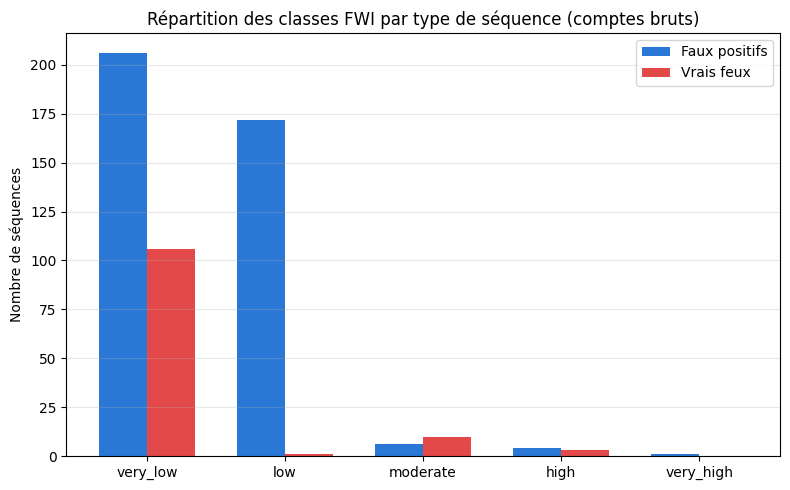

In [ ]:
# Répartition FWI x label (comptes bruts)
fwi_order = ["very_low", "low", "moderate", "high", "very_high", "extreme"]
counts = pd.crosstab(df["label"], df["fwi_class"])
counts = counts.reindex(columns=[c for c in fwi_order if c in counts.columns], fill_value=0)

x = np.arange(len(counts.columns))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, counts.loc["fp"], width, label="Faux positifs", color="#2a78d6")
ax.bar(x + width/2, counts.loc["wildfire"], width, label="Vrais feux", color="#e34948")

ax.set_xticks(x)
ax.set_xticklabels(counts.columns)
ax.set_ylabel("Nombre de séquences")
ax.set_title("Répartition des classes FWI par type de séquence (comptes bruts)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fwi_repartition_comptes.png", dpi=150)
plt.show()

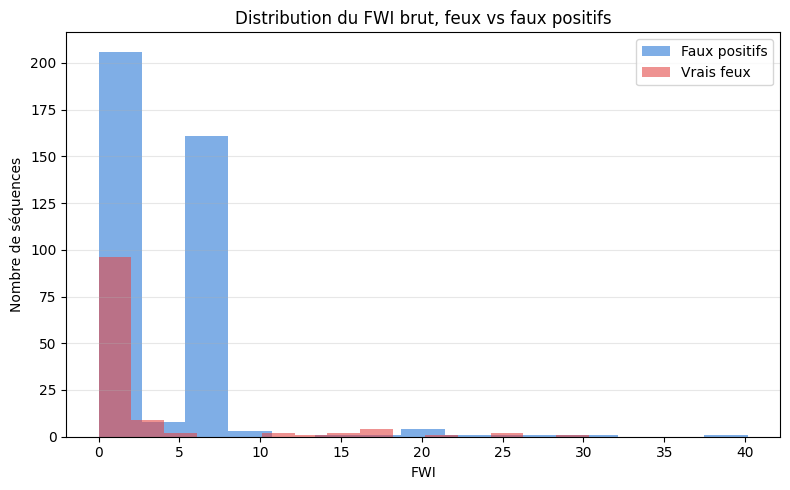

In [11]:
# Distribution du FWI brut (valeur continue, pas la classe), feux vs FP
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df["label"] == "fp"]["fwi"].dropna(), bins=15, alpha=0.6, label="Faux positifs", color="#2a78d6")
ax.hist(df[df["label"] == "wildfire"]["fwi"].dropna(), bins=15, alpha=0.6, label="Vrais feux", color="#e34948")

ax.set_xlabel("FWI")
ax.set_ylabel("Nombre de séquences")
ax.set_title("Distribution du FWI brut, feux vs faux positifs")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fwi_distribution_brute.png", dpi=150)
plt.show()

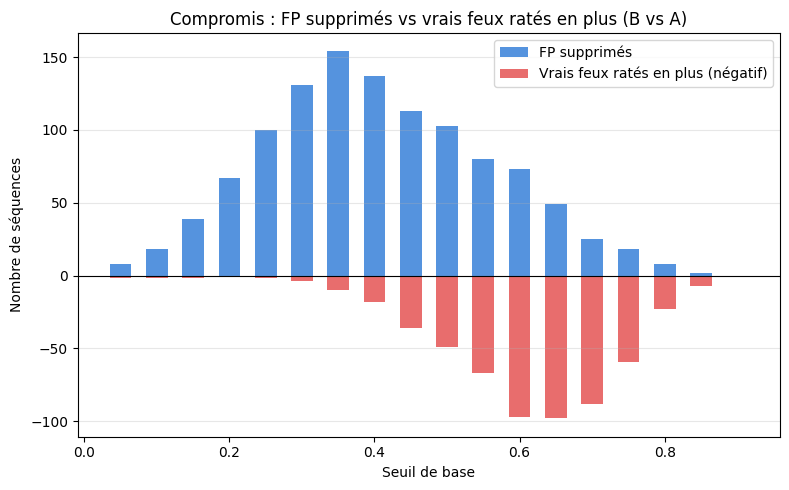

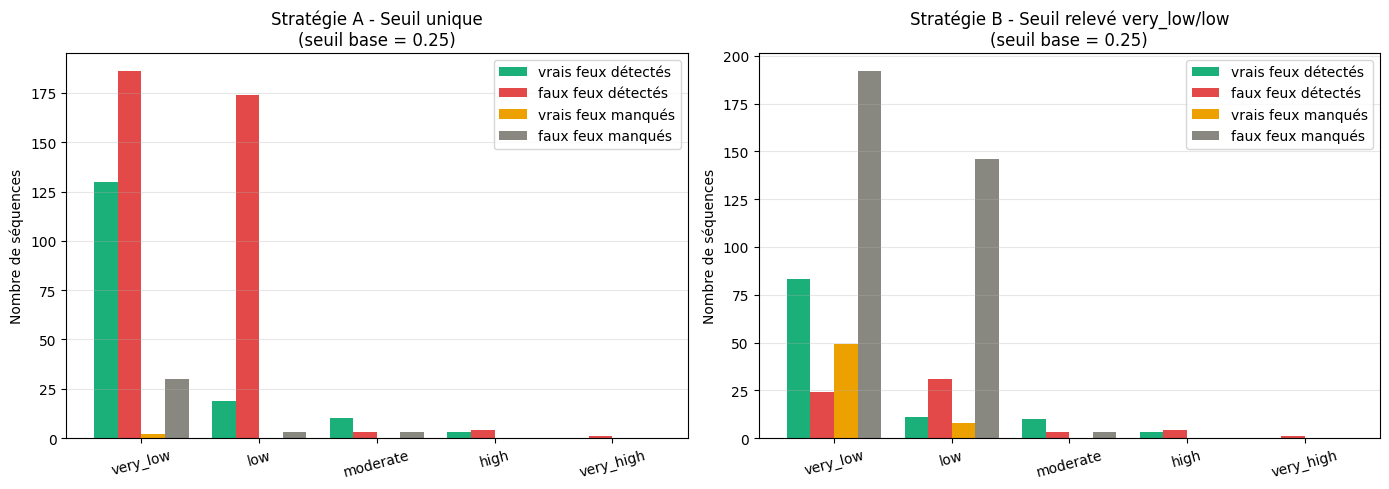

In [20]:

# On ne garde que les séquences avec un FWI connu
df_eval = df[df["fwi_class"].notna()].copy()
BASE_THRESHOLD = 0.25

FWI_ORDER = ["very_low", "low", "moderate", "high", "very_high", "extreme"]

def apply_rule(df, seuil, seuil_classe):
    
    def get_seuil(fwi_class):
        return seuil_classe.get(fwi_class, seuil)
    
    thresholds = df["fwi_class"].map(get_seuil)
    predicted_fire = df["score_max"] > thresholds
    return predicted_fire #recupere les feux au dessus du seuil, selon la classe FWI

def compute_metrics(df, predicted_fire):
    y_true = df["label"].isin(["wildfire", "smoke"])
    vrai_feu_detecté = (predicted_fire &  y_true).sum()
    faux_feu_detecté = (predicted_fire & ~y_true).sum()
    faux_feu_manqués = (~predicted_fire &  y_true).sum()
    vrai_feu_manqués = (~predicted_fire & ~y_true).sum()
    precision = vrai_feu_detecté / (vrai_feu_detecté + faux_feu_detecté) if (vrai_feu_detecté + faux_feu_detecté) > 0 else 0
    recall    = vrai_feu_detecté / (vrai_feu_detecté + faux_feu_manqués) if (vrai_feu_detecté + faux_feu_manqués) > 0 else 0
    return dict(tp=vrai_feu_detecté, fp=faux_feu_detecté, fn=faux_feu_manqués, tn=vrai_feu_manqués,
                precision=precision, recall=recall)

#on va tenter des seuils qui varient

thresholds = np.arange(0.05, 0.95, 0.05)

# Stratégie A : seuil unique
results_A = []
for t in thresholds:
    pred = apply_rule(df_eval, seuil=t, seuil_classe={})
    m = compute_metrics(df_eval, pred)
    m["threshold"] = t
    results_A.append(m)
df_A = pd.DataFrame(results_A)

# Stratégie B : seuil relevé sur very_low (+0.2) et low (+0.1)
results_B = []
for t in thresholds:
    pred = apply_rule(df_eval, seuil=t,
                      seuil_classe={"very_low": t + 0.2, "low": t + 0.1})
    m = compute_metrics(df_eval, pred)
    m["threshold"] = t
    results_B.append(m)
df_B = pd.DataFrame(results_B)

# combien de FP en moins avec la stratégie B par rapport à A ?

df_compare = pd.DataFrame({
    "threshold": thresholds,
    "fp_A": df_A["fp"].values,
    "fp_B": df_B["fp"].values,
    "fn_A": df_A["fn"].values,
    "fn_B": df_B["fn"].values,
})
df_compare["fp_supprimes"] = df_compare["fp_A"] - df_compare["fp_B"]
df_compare["feux_rates_en_plus"] = df_compare["fn_B"] - df_compare["fn_A"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_compare["threshold"], df_compare["fp_supprimes"],
       width=0.03, color="#2a78d6", alpha=0.8, label="FP supprimés")
ax.bar(df_compare["threshold"], -df_compare["feux_rates_en_plus"],
       width=0.03, color="#e34948", alpha=0.8, label="Vrais feux ratés en plus (négatif)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Seuil de base")
ax.set_ylabel("Nombre de séquences")
ax.set_title("Compromis : FP supprimés vs vrais feux ratés en plus (B vs A)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("compromis_fp_fn.png", dpi=150)
plt.show()

SEUIL_CLASSE = {"very_low": 0.7, "low": 0.6}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (strat_name, fwi_thr) in zip(axes, [
    ("A - Seuil unique", {}),
    ("B - Seuil relevé very_low/low", SEUIL_CLASSE)
]):
    records = []
    for fwi_cls in FWI_ORDER:
        sub = df_eval[df_eval["fwi_class"] == fwi_cls]
        if len(sub) == 0:
            continue
        pred = apply_rule(sub, BASE_THRESHOLD, fwi_thr)
        m = compute_metrics(sub, pred)
        records.append({"fwi_class": fwi_cls, **m})
    
    df_conf = pd.DataFrame(records).set_index("fwi_class")
    
    x = np.arange(len(df_conf))
    w = 0.2
    ax.bar(x - 1.5*w, df_conf["tp"], w, label="vrais feux détectés", color="#1baf7a")
    ax.bar(x - 0.5*w, df_conf["fp"], w, label="faux feux détectés", color="#e34948")
    ax.bar(x + 0.5*w, df_conf["fn"], w, label="vrais feux manqués", color="#eda100")
    ax.bar(x + 1.5*w, df_conf["tn"], w, label="faux feux manqués", color="#888780")
    
    ax.set_xticks(x)
    ax.set_xticklabels(df_conf.index, rotation=15)
    ax.set_ylabel("Nombre de séquences")
    ax.set_title(f"Stratégie {strat_name}\n(seuil base = {BASE_THRESHOLD})")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("confusion_par_fwi_class.png", dpi=150)
plt.show()